# 05 - Evaluation
Evaluate the trained model and inspect predictions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

train = pd.read_csv("../data/raw/mnist_train.csv")
X = train.drop(columns=["label"]).values.astype("float32") / 255.0
y = train["label"].values
X = X.reshape(-1, 28, 28, 1)

model = keras.models.load_model("../models/mnist_digit_model.keras")
loss, accuracy = model.evaluate(X, y, verbose=0)
print("Accuracy:", accuracy)


Accuracy: 0.9946833252906799


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       479
           1       0.99      1.00      0.99       563
           2       0.99      0.99      0.99       488
           3       0.99      0.99      0.99       493
           4       1.00      1.00      1.00       535
           5       1.00      0.99      0.99       434
           6       1.00      1.00      1.00       501
           7       1.00      0.99      1.00       550
           8       0.99      0.99      0.99       462
           9       0.99      0.99      0.99       495

    accuracy                           0.99      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000



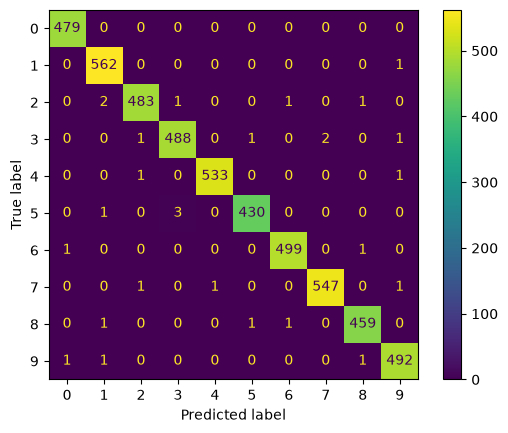

In [2]:
pred = model.predict(X[:5000], verbose=0).argmax(axis=1)
print(classification_report(y[:5000], pred))
ConfusionMatrixDisplay(confusion_matrix(y[:5000], pred)).plot()
plt.show()


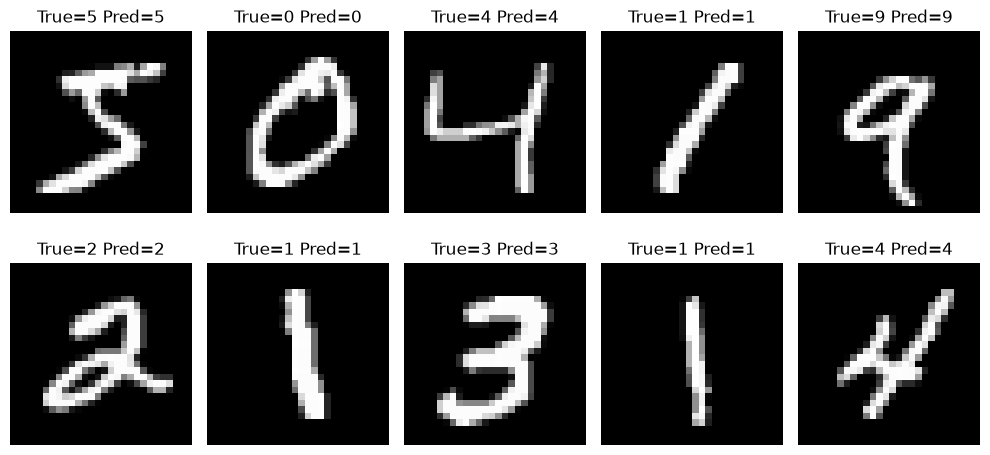

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10,5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X[i].squeeze(), cmap="gray")
    ax.set_title(f"True={y[i]} Pred={pred[i]}")
    ax.axis("off")
plt.tight_layout()
